In [4]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '..')

print("Ready!")

Ready!


In [7]:
from src.data.acdc_dataset import ACDCDataset

dataset = ACDCDataset('../data/training')
records = dataset.load_all()
df = pd.DataFrame(records)

print(f"Tong: {len(df)} benh nhan")
print(f"\nPhân bố nhóm bệnh:")
print(df['group'].value_counts())

[ACDC] Tim thay 100 benh nhan
[ACDC] Load 100 benh nhan (bo qua 0)
Tong: 100 benh nhan

Phân bố nhóm bệnh:
group
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [8]:
metrics = ['LV_EDV', 'LV_ESV', 'LV_EF', 'RV_EDV', 'RV_ESV', 'RV_EF', 'Myo_mass']
df[metrics].describe().round(1)

,LV_EDV,LV_ESV,LV_EF,RV_EDV,RV_ESV,RV_EF,Myo_mass
count,100.0,100.0,100.0,100.0,100.0,100.0,100.0
mean,164.6,99.1,46.4,153.0,85.9,46.7,138.7
std,74.3,78.8,19.9,55.2,52.5,17.9,53.5
min,49.3,19.4,10.5,47.4,10.3,1.9,37.8
25%,118.1,41.8,28.0,111.8,51.6,38.2,99.6
50%,149.0,64.1,53.7,152.0,70.1,48.4,132.7
75%,199.8,132.6,62.2,181.7,108.2,60.0,170.6
max,374.4,334.5,81.9,295.1,262.8,85.9,281.0


C:\Users\T.Hung\AppData\Local\Temp\ipykernel_23880\3251566058.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_group, labels=groups)


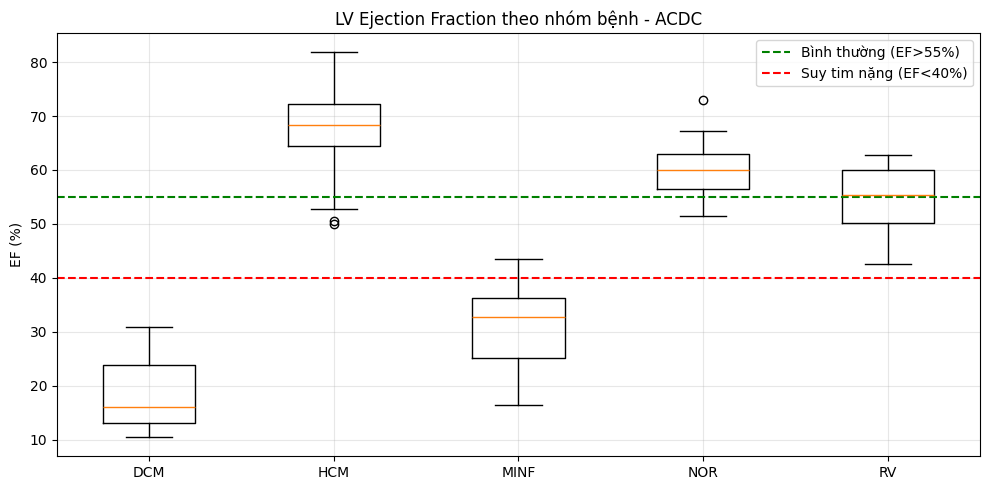

In [9]:
groups = df['group'].unique()
data_by_group = [df[df['group'] == g]['LV_EF'].values for g in groups]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data_by_group, labels=groups)
ax.axhline(55, color='green', linestyle='--', label='Bình thường (EF>55%)')
ax.axhline(40, color='red',   linestyle='--', label='Suy tim nặng (EF<40%)')
ax.set_title('LV Ejection Fraction theo nhóm bệnh - ACDC')
ax.set_ylabel('EF (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
from src.metrics.clinical_metrics import simulate_predictions

# Split 40/30/30
rng = np.random.default_rng(42)
idx = rng.permutation(len(df))

idx_cal  = idx[40:70]   # 30 benh nhan calibration
idx_test = idx[70:]     # 30 benh nhan test

print(f"Calibration: {len(idx_cal)} benh nhan")
print(f"Test       : {len(idx_test)} benh nhan")

# Simulate predictions (10% noise)
metric = 'LV_EF'
true_all = df[metric].values
pred_all = simulate_predictions(true_all, rel_noise=0.10, seed=42)

cal_true  = true_all[idx_cal]
cal_pred  = pred_all[idx_cal]
test_true = true_all[idx_test]
test_pred = pred_all[idx_test]

print(f"\nMAE (LV_EF): {np.abs(pred_all - true_all).mean():.2f}%")

Calibration: 30 benh nhan
Test       : 30 benh nhan

MAE (LV_EF): 2.94%


In [11]:
from src.conformal.split_conformal import calibrate, predict_interval, evaluate_coverage

# Calibrate tren cal set
cp = calibrate(cal_true, cal_pred, alpha=0.10, mode='abs')

print(f"Conformal quantile q_hat = {cp['q_hat']:.2f}%")
print(f"(Interval width se la ± {cp['q_hat']:.2f}%)")

# Predict intervals tren test set
lo, hi = predict_interval(test_pred, cp['q_hat'], mode='abs')

# Evaluate
result = evaluate_coverage(test_true, lo, hi)
print(f"\nKet qua tren test set:")
print(f"  Empirical coverage : {result['coverage']*100:.1f}%  (target: 90%)")
print(f"  Mean interval width: {result['mean_width']:.2f}%")
print(f"  Covered            : {result['n_covered']}/{result['n_test']} benh nhan")

Conformal quantile q_hat = 7.95%
(Interval width se la ± 7.95%)

Ket qua tren test set:
  Empirical coverage : 93.3%  (target: 90%)
  Mean interval width: 15.89%
  Covered            : 28/30 benh nhan


Giả lập model predictions

In [ ]:
import numpy as np

np.random.seed(42)

# Gia lap: model du doan voi sai so ~10-15% 
# (tuong duong nnU-Net tren ACDC)
rel_error = 0.12  # 12% relative error

true_lv_edv = np.array([r['LV_EDV'] for r in records])
true_lv_esv = np.array([r['LV_ESV'] for r in records])
true_lv_ef  = np.array([r['LV_EF']  for r in records])
groups      = np.array([r['group']   for r in records])

# Them noise ty le voi gia tri that
pred_lv_edv = true_lv_edv * (1 + rel_error * np.random.randn(len(records)))
pred_lv_esv = true_lv_esv * (1 + rel_error * np.random.randn(len(records)))

# Tinh EF tu predicted volumes
pred_lv_ef = np.clip((pred_lv_edv - pred_lv_esv) / pred_lv_edv * 100, 0, 100)

print(f"True  LV_EF: mean={true_lv_ef.mean():.1f}%  std={true_lv_ef.std():.1f}%")
print(f"Pred  LV_EF: mean={pred_lv_ef.mean():.1f}%  std={pred_lv_ef.std():.1f}%")
print(f"MAE LV_EF  : {np.abs(pred_lv_ef - true_lv_ef).mean():.2f}%")
print(f"\nTong: {len(records)} benh nhan san sang cho conformal prediction!")

True  LV_EF: mean=46.4%  std=19.8%
Pred  LV_EF: mean=45.3%  std=21.9%
MAE LV_EF  : 6.99%

Tong: 100 benh nhan san sang cho conformal prediction!


In [ ]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Khong co")

2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
